In [14]:
import math

# decision tree implementation
def get_dataset():
    dataset = [
        [0, 2, 0, 0, 'no'],
        [0, 2, 0, 1, 'no'],
        [1, 2, 0, 0, 'yes'],
        [2, 1, 0, 0, 'yes'],
        [2, 0, 1, 0, 'yes'],
        [2, 0, 1, 1, 'no'],
        [1, 0, 1, 1, 'yes'],
        [0, 1, 0, 0, 'no'],
        [0, 0, 1, 0, 'yes'],
        [2, 1, 1, 0, 'yes'],
        [0, 1, 1, 1, 'yes'],
        [1, 1, 0, 1, 'yes'],
        [1, 2, 1, 0, 'yes'],
        [2, 1, 0, 1, 'no'],
        [0, 2, 1, 0, 'no'],
        [1, 2, 1, 1, 'yes'],
        [2, 2, 0, 1, 'yes'],
        [0, 0, 0, 1, 'no'],
        [1, 1, 1, 0, 'yes'],
        [2, 2, 1, 0, 'yes'],
        [0, 1, 0, 1, 'no'],
        [1, 0, 0, 0, 'no'],
        [2, 1, 0, 1, 'no'],
        [0, 2, 1, 1, 'yes'],
        [1, 2, 0, 1, 'yes'],
        [2, 0, 0, 0, 'no'],
        [0, 0, 1, 1, 'yes'],
        [1, 1, 1, 1, 'yes'],
        [2, 2, 1, 1, 'yes'],
        [0, 1, 1, 0, 'yes']
    ]
    labels = ["label_one", "label_two", "label_three", "label_four"]
    return dataset, labels

# use recursion method build the tree
def buildTree(dataset, labels, chosenFeatureLabels, maxDepth=None, currentDepth=0):
    classList = [sample[-1] for sample in dataset]
    # stop1: the first condition to stop the recursion
    if classList.count(classList[0]) == len(classList):
        return classList[0]
    # stop2: the second condition to stop the recursion
    if len(dataset[0]) == 1:
        return getMajorityof(classList)
    # stop3: hyperparameter Max Depth
    if maxDepth is not None and currentDepth >= maxDepth:
        return getMajorityof(classList)

    bestFeature, _ = findBestFeatureToSplit(dataset)  # this function return an index
    print("bestFeature", bestFeature)
    bestFeatureLabel = labels[bestFeature]
    chosenFeatureLabels.append(bestFeatureLabel)

    # create node keyed by feature label
    treeModel = {bestFeatureLabel: {}}

    # prepare labels for children: remove used feature (on a copy)
    subLabels = labels[:]
    del subLabels[bestFeature]

    featureValues = [line[bestFeature] for line in dataset]
    uniqueFeatureValues = set(featureValues)

    for value in uniqueFeatureValues:
        # for each branch, pass a fresh copy of subLabels
        treeModel[bestFeatureLabel][value] = buildTree(
            splitDataSet(dataset, bestFeature, value),
            subLabels[:],
            chosenFeatureLabels,
            maxDepth = maxDepth,
            currentDepth = currentDepth + 1
        )

    return treeModel

## find the majority class for recent dataset
def getMajorityof(classList):
    countClass = countLabels(classList)
    sorted_items = sorted(countClass.items(), key = lambda item: item[1], reverse=True)
    return sorted_items[0][0]

### a general tool function used to count label numbers in a list
def countLabels(labelList):
    countClass = {}
    for Label in labelList:
        if Label not in countClass.keys(): 
            countClass[Label] = 0
        countClass[Label] += 1
    return countClass


## use entropy (Infomation Gain) find best feature for recent branch
def findBestFeatureToSplit(dataset):
    totalNumberOfFeature = len(dataset[0]) - 1
    basicEntropy = calEntropy(dataset)
    bestInfomationGain = 0
    bestFeature = -1 
    for i in range(totalNumberOfFeature):
        featureValueList = [sample[i] for sample in dataset]
        uniqueFeatureValue = set(featureValueList)
        localEntropy = 0
        for fValue in uniqueFeatureValue:
            subDataSet = splitDataSet(dataset, i, fValue)
            percentage = len(subDataSet) / float(len(dataset))
            localEntropy += percentage * calEntropy(subDataSet)
        localInfomationGain = basicEntropy - localEntropy
        if (localInfomationGain > bestInfomationGain):
            bestInfomationGain = localInfomationGain
            bestFeature = i
    return bestFeature, bestInfomationGain

## calculate the Entropy of dataset
def calEntropy(dataset):
    totalNumberOfSamples = len(dataset)
    countClass = countLabels([sample[-1] for sample in dataset])
    entropy = 0
    for key in countClass.keys():
        prob = float(countClass[key]) / totalNumberOfSamples
        entropy -= prob * math.log(prob, 2)
    return entropy



## split the dataset which used by next subtree node (also maybe leave)
def splitDataSet(dataset, recentFeatureIndex, oneValueInRecentFeature):
    resDataset = []
    for sample in dataset:
        if sample[recentFeatureIndex] == oneValueInRecentFeature:
            resSample = sample[:recentFeatureIndex]
            resSample.extend(sample[recentFeatureIndex+1:])
            resDataset.append(resSample)
    return resDataset



if __name__ == "__main__":
    dataset, labels = get_dataset()
    featLabels = []
    treeModel = buildTree(dataset, labels, featLabels, maxDepth=2)
    print(treeModel)
    


bestFeature 2
bestFeature 0
bestFeature 0
{'label_three': {0: {'label_one': {0: 'no', 1: 'yes', 2: 'no'}}, 1: {'label_one': {0: 'yes', 1: 'yes', 2: 'yes'}}}}


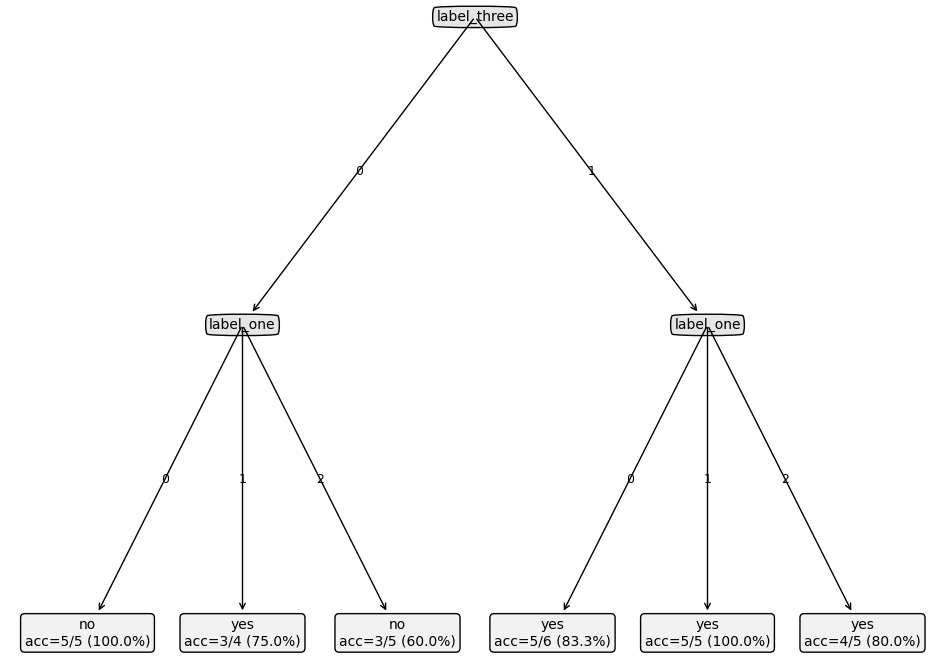

In [15]:
import matplotlib.pyplot as plt

# ---------- helpers ----------
decisionNode = dict(boxstyle="round4", fc="0.9")
leafNode = dict(boxstyle="round", fc="0.95")
arrow_args = dict(arrowstyle="<-")

def get_num_leafs(tree):
    if not isinstance(tree, dict):
        return 1
    root = next(iter(tree))
    children = tree[root]
    num_leafs = 0
    for child in children.values():
        num_leafs += get_num_leafs(child)
    return num_leafs

def get_tree_depth(tree):
    if not isinstance(tree, dict):
        return 1
    root = next(iter(tree))
    children = tree[root]
    max_depth = 0
    for child in children.values():
        this_depth = 1 + (get_tree_depth(child) - 1 if isinstance(child, dict) else 1 - 1)
        # simpler equivalent: this_depth = 1 if leaf else 1 + get_tree_depth(child)
        if isinstance(child, dict):
            this_depth = 1 + get_tree_depth(child)
        else:
            this_depth = 1
        max_depth = max(max_depth, this_depth)
    return max_depth

def plot_node(node_txt, center_pt, parent_pt, node_type):
    create_plot.ax1.annotate(
        node_txt,
        xy=parent_pt, xycoords='axes fraction',
        xytext=center_pt, textcoords='axes fraction',
        va="center", ha="center",
        bbox=node_type, arrowprops=arrow_args
    )

def plot_mid_text(cntr_pt, parent_pt, txt_string):
    x_mid = (parent_pt[0] + cntr_pt[0]) / 2.0
    y_mid = (parent_pt[1] + cntr_pt[1]) / 2.0
    create_plot.ax1.text(x_mid, y_mid, txt_string, va="center", ha="center", fontsize=9)

def plot_tree(tree, parent_pt, node_txt, branch_dataset, branch_labels):
    num_leafs = get_num_leafs(tree)
    root = next(iter(tree))
    cntr_pt = (plot_tree.x_off + (1.0 + num_leafs) / 2.0 / plot_tree.total_w, plot_tree.y_off)

    plot_mid_text(cntr_pt, parent_pt, node_txt)
    plot_node(str(root), cntr_pt, parent_pt, decisionNode)

    children = tree[root]
    root_feature_index = branch_labels.index(root)
    plot_tree.y_off -= 1.0 / plot_tree.total_d

    for edge_val, child in children.items():
        child_dataset = splitDataSet(branch_dataset, root_feature_index, edge_val)
        child_labels = branch_labels[:]
        del child_labels[root_feature_index]

        if isinstance(child, dict):
            plot_tree(child, cntr_pt, str(edge_val), child_dataset, child_labels)
        else:
            plot_tree.x_off += 1.0 / plot_tree.total_w
            leaf_pt = (plot_tree.x_off, plot_tree.y_off)
            plot_mid_text(leaf_pt, cntr_pt, str(edge_val))

            total = len(child_dataset)
            correct = sum(1 for sample in child_dataset if sample[-1] == child)
            rate = (correct / total) if total else 0.0
            leaf_text = f"{child}\nacc={correct}/{total} ({rate:.1%})"
            plot_node(leaf_text, leaf_pt, cntr_pt, leafNode)

    plot_tree.y_off += 1.0 / plot_tree.total_d

def create_plot(tree, dataset, labels):
    fig = plt.figure(figsize=(12, 8), facecolor='white')
    fig.clf()
    axprops = dict(xticks=[], yticks=[])
    create_plot.ax1 = plt.subplot(111, frameon=False, **axprops)

    plot_tree.total_w = float(get_num_leafs(tree))
    plot_tree.total_d = float(get_tree_depth(tree))
    plot_tree.x_off = -0.5 / plot_tree.total_w
    plot_tree.y_off = 1.0

    plot_tree(tree, (0.5, 1.0), '', dataset, labels)
    plt.show()

create_plot(treeModel, dataset, labels[:])